In [1]:
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

# import some common libraries
import numpy as np
import os, json, cv2, random, importlib
import matplotlib.pyplot as plt

# import some common detectron2 utilities
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog
import random
import cv2
import matplotlib.pyplot as plt
from detectron2.utils.visualizer import Visualizer, ColorMode

# import our functions 
os.chdir("../../util/preprocessing")
import tumor_dataset

importlib.reload(tumor_dataset)
from tumor_dataset import Dataset

In [2]:
from detectron2.data.datasets import register_coco_instances
d = Dataset(data_path="../../data/raw_data/useable_data")
d.convert_binary_to_coco()

register_coco_instances("my_dataset_train", {}, "../../data/processed_data/train/images/train.json", "../../data/processed_data/train/images/")
register_coco_instances("my_dataset_val", {}, "../../data/processed_data/val/images/val.json", "../../data/processed_data/val/images/")
register_coco_instances("my_dataset_test", {}, "../../data/processed_data/test/images/test.json", "../../data/processed_data/test/images/")

Created 613 annotations for images in folder: /Users/abirmodak/Documents/tumor/data/processed_data/train/masks
Created 259 annotations for images in folder: /Users/abirmodak/Documents/tumor/data/processed_data/val/masks
Created 28 annotations for images in folder: /Users/abirmodak/Documents/tumor/data/processed_data/test/masks


In [3]:
train_metadata = MetadataCatalog.get("my_dataset_train")
train_dataset_dicts = DatasetCatalog.get("my_dataset_train")

val_metadata = MetadataCatalog.get("my_dataset_val")
val_dataset_dicts = DatasetCatalog.get("my_dataset_val")

test_metadata = MetadataCatalog.get("my_dataset_test")
test_dataset_dicts = DatasetCatalog.get("my_dataset_test")

[07/01 05:23:55 d2.data.datasets.coco]: Loaded 220 images in COCO format from ../../data/processed_data/train/images/train.json
[07/01 05:23:55 d2.data.datasets.coco]: Loaded 27 images in COCO format from ../../data/processed_data/val/images/val.json
[07/01 05:23:55 d2.data.datasets.coco]: Loaded 28 images in COCO format from ../../data/processed_data/test/images/test.json


Image file: ../../data/processed_data/val/images/val_19.jpg
Mask file: ../../data/processed_data/val/masks/Tumor/val_19.png


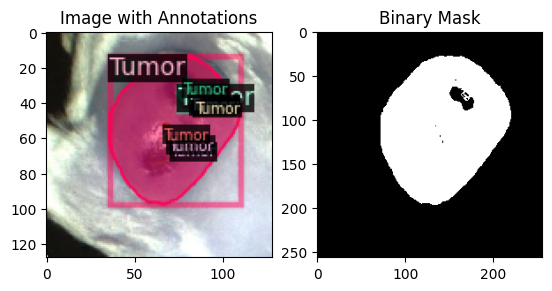

In [6]:
mask_folder = "../../data/processed_data/val/masks/Tumor"  # Update with your binary mask folder path

for d in random.sample(val_dataset_dicts, 1):
    # Load the image
    img = cv2.imread(d["file_name"])

    print(f"Image file: {d['file_name']}")
    
    # Check if the image was successfully loaded
    if img is None:
        print(f"Failed to load image: {d['file_name']}")
        continue

    # Visualize the image with annotations
    visualizer = Visualizer(img[:, :, ::-1], metadata=val_metadata, scale=0.5)
    vis = visualizer.draw_dataset_dict(d)

    # Display the annotated image
    plt.subplot(1, 2, 1)  # 1 row, 2 columns, first subplot
    plt.imshow(vis.get_image()[:, :, ::-1])
    plt.title("Image with Annotations")

    # Load the corresponding binary mask
    image_base_name = os.path.basename(d["file_name"]).split(".")[0]  # Get base name of the image
    mask_path = os.path.join(mask_folder, f"{image_base_name}.png")  # Assuming masks have .jpg extension

    print(f"Mask file: {mask_path}")
    
    # Load the binary mask
    mask_img = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    # Check if the mask was successfully loaded
    if mask_img is None:
        print(f"Failed to load mask: {mask_path}")
        continue

    # Display the binary mask
    plt.subplot(1, 2, 2)  # 1 row, 2 columns, second subplot
    plt.imshow(mask_img, cmap="gray")
    plt.title("Binary Mask")

    plt.show()  # Display the images side by side

now essentially what we want to do here is create a sub class of the default trainer so we can implement image augmentations.
These augmentations were defined by the medsam2 paper, seemed good enough to use here 

In [8]:
from detectron2.engine import DefaultTrainer
from detectron2.data import build_detection_train_loader, DatasetMapper
from detectron2.data import transforms as T
import cv2

class TrainerWithAug(DefaultTrainer):
    @classmethod
    def build_train_loader(cls, cfg):
        augmentations = [
            # 1. Rotation: prob 0.15, angle ~ Uniform[-25,25]
            T.RandomApply(
                T.RandomRotation(angle=[-25, 25], expand=False), prob=0.15
            ),

            # 2. Scaling: prob 0.15, scale ~ Uniform[0.7, 1.4]
            T.RandomApply(
                T.ResizeScale(
                    scale_min=0.7, scale_max=1.4,
                    target_height=None, target_width=None,
                    interp=cv2.INTER_LINEAR
                ), prob=0.15
            ),

            # 3. Gaussian Noise: prob 0.15, var ~ Uniform[0, 0.1]
            T.RandomApply(
                T.RandomNoise(
                    mean=0.0, std=np.sqrt(0.1),  # std = sqrt(max variance)
                    is_symmetric=True
                ),
                prob=0.15
            ),

            # 4. Gaussian Blur: prob 0.15, sigma ~ Uniform[0.5, 1.5]
            T.RandomApply(
                T.GaussianBlur(
                    sigma_min=0.5, sigma_max=1.5,
                    kernel_size=0  # 0 → auto from sigma
                ),
                prob=0.15
            ),

            # 5. Intensity Adjustment: prob 0.15, factor ~ Uniform[0.65, 1.2]
            T.RandomApply(
                [
                    T.RandomBrightness(0.65, 1.2),
                    # optionally flip: T.RandomApply( T.FlipBrightness(), prob=0.5)
                ],
                prob=0.15
            ),

            # 6. Low Resolution: prob 0.25, downscale by Uniform[1,2], then upsample
            T.RandomApply(
                T.ResizeScale(
                    scale_min=1/2.0,  # invert max downscale
                    scale_max=1.0,
                    target_height=None, target_width=None,
                    interp=cv2.INTER_NEAREST
                ),
                prob=0.25
            ),
            # after the down‐sampling, upsample back to original:
            T.RandomApply(
                T.ResizeScale(
                    scale_min=1.0, scale_max=2.0,
                    target_height=None, target_width=None,
                    interp=cv2.INTER_CUBIC
                ),
                prob=0.25
            ),

            # + you can still keep your resize‐to‐range and flip
            T.ResizeShortestEdge(short_edge_length=(640, 800),
                                 max_size=1333, sample_style="choice"),
            T.RandomFlip(prob=0.5, direction="horizontal"),
        ]

        # 2) Build a mapper that DOES NOT filter out empty (negative) images
        mapper = DatasetMapper(
            cfg, is_train=True,
            augmentations=augmentations,
            image_format="BGR",
            mask_format="bitmask",
            filter_empty=False,   # ← keep negatives
        )

        # 3) Return the standard loader built with your mapper
        return build_detection_train_loader(cfg, mapper=mapper)


In [9]:
from detectron2.engine import DefaultTrainer

cfg = get_cfg()
cfg.OUTPUT_DIR = '../models/detectron2'
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg.DATASETS.TRAIN = ("my_dataset_train",)
cfg.DATASETS.TEST = ("my_dataset_val")
cfg.DATALOADER.NUM_WORKERS = 2
cfg.DATALOADER.FILTER_EMPTY_ANNOTATIONS = False # this is for our "no tumor" examples 
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")  # Let training initialize from model zoo
cfg.SOLVER.IMS_PER_BATCH = 2  # This is the real "batch size" commonly known to deep learning people
cfg.SOLVER.BASE_LR = 0.00025  # pick a good LR
cfg.SOLVER.MAX_ITER = 1000    
cfg.SOLVER.STEPS = []        
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 512   # The "RoIHead batch size". 128 is faster, and good enough for this toy dataset (default: 512)
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1  
# NOTE: this config means the number of classes, but a few popular unofficial tutorials incorrect uses num_classes+1 here.

os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
trainer = TrainerWithAug(cfg)
trainer.resume_or_load(resume=False)
trainer.train()

AssertionError: Torch not compiled with CUDA enabled

In [9]:
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")  # path to the model we just trained
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5   # set a custom testing threshold
predictor = DefaultPredictor(cfg)

[09/29 06:41:34 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ../models/detectron2/model_final.pth ...


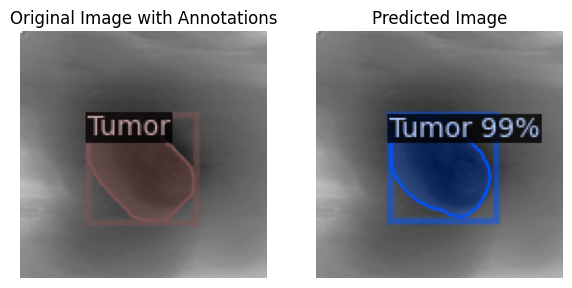

In [ ]:
# Function to display the original image with annotations and the predicted image
def display_original_and_prediction_with_annotations(val_dataset_dicts, predictor, val_metadata):
    for d in random.sample(val_dataset_dicts, 1):  # Select number of images for display
        im = cv2.imread(d["file_name"])
        outputs = predictor(im)
        
        # Create a visualizer object for the original image with annotations
        v_gt = Visualizer(im[:, :, ::-1],
                          metadata=val_metadata,
                          scale=0.5
        )
        out_gt = v_gt.draw_dataset_dict(d)
        
        # Create a visualizer object for the predicted image
        v_pred = Visualizer(im[:, :, ::-1],
                            metadata=val_metadata,
                            scale=0.5,
                            instance_mode=ColorMode.IMAGE_BW  # Remove the colors of unsegmented pixels
        )
        out_pred = v_pred.draw_instance_predictions(outputs["instances"].to("cpu"))
        
        # Set up subplots
        fig, ax = plt.subplots(1, 2, figsize=(7,7))
        
        # Display the original image with annotations
        ax[0].imshow(out_gt.get_image()[:, :, ::-1])
        ax[0].set_title('Original Image with Annotations')
        
        # Display the predicted image
        ax[1].imshow(out_pred.get_image()[:, :, ::-1])
        ax[1].set_title('Predicted Image')

        for a in ax:
            a.axis("off")
        
        plt.show()

# Example usage
display_original_and_prediction_with_annotations(val_dataset_dicts, predictor, test_metadata)


In [15]:
def save_all_images(val_dataset_dicts, predictor, val_metadata, output_dir):
    
    #create image path if it doesnt exist 
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    for i, d in enumerate(val_dataset_dicts):

        im = cv2.imread(d["file_name"])
        outputs = predictor(im)
        
        v_gt = Visualizer(im[:, :, ::-1], metadata=val_metadata, scale=0.5)
        out_gt = v_gt.draw_dataset_dict(d)
        
        v_pred = Visualizer(im[:, :, ::-1], metadata=val_metadata, scale=0.5, instance_mode=ColorMode.IMAGE_BW)
        out_pred = v_pred.draw_instance_predictions(outputs["instances"].to("cpu"))
        
        fig, ax = plt.subplots(1, 2, figsize=(30, 30))

        ax[0].imshow(out_gt.get_image()[:, :, ::-1])
        ax[0].set_title('Image with Original Annotations', fontsize=24)
        ax[0].axis('off')
        
        # Display the predicted image
        ax[1].imshow(out_pred.get_image()[:, :, ::-1])
        ax[1].set_title('Images with Annotations produced by the model', fontsize=24)
        ax[1].axis('off')
        
        fig.savefig(os.path.join(output_dir, f"image_{i}.png"), bbox_inches="tight")
        plt.close(fig) 

In [16]:
save_all_images(test_dataset_dicts, predictor, test_metadata, './detectron2/images_rgb')